# Linear Regression

This section is for pratice and save notes about all learned of this model.

This model is of supervised class. All supervised class refer when in your data you have the value that you try to predict

## Mathematical formula
y_pred = xw - b

*Where*:
- y_pred: y predicted
- x: feature of that affect y
- w: weight or pendient or slope
- b: bias

In [34]:
# import all libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [17]:
# see summaryse of dataset
df = pd.read_csv('./data/houses.csv')
df.head()

,metros_cuadrados,precio
0,50,100000
1,100,180000
2,80,145000
3,120,210000
4,60,115000


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   metros_cuadrados  10 non-null     int64
 1   precio            10 non-null     int64
dtypes: int64(2)
memory usage: 292.0 bytes


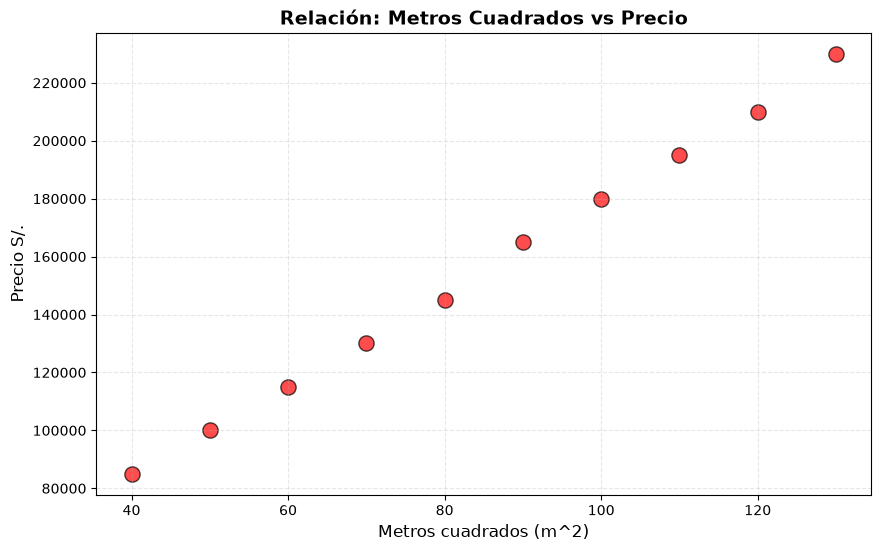

In [12]:
# maket graphic
plt.figure(figsize=(10, 6))

# points
plt.scatter(
    df['metros_cuadrados'],
    df['precio'],
    color='red',
    s=120, # size points
    alpha=0.7, # transparents
    edgecolors='black',
    linewidths=1
)

# labels
plt.title('Relación: Metros Cuadrados vs Precio', fontsize=14, fontweight='bold')
plt.xlabel('Metros cuadrados (m^2)', fontsize=12)
plt.ylabel('Precio S/.', fontsize=12)

# cuadricula
plt.grid(True, alpha=0.3, linestyle='--')
plt.show()

In [51]:

def training_epoch(df, w = 0, b = 0):
    n = len(df) # total data
    sum_mae = 0
    sum_mse = 0
    sum_grad_w = 0
    sum_grad_b = 0
    for index, row in df.iterrows():
        x = float(row['metros_cuadrados'])
        y = float(row['precio'])

        # y predicted or hypothesis
        y_pred = (x * w) + b

        # sum for mae
        error_mae = abs(y - y_pred)
        sum_mae += error_mae

        # sum for mse
        error_mse = (y - y_pred) ** 2
        sum_mse += error_mse

        # sum for w
        sum_grad_w += (y_pred - y) * x

        # sum for b
        sum_grad_b += (y_pred - y)

    # loss function | mean squared error
    mse = sum_mse / (2*n)

    # get mae value
    mae = sum_mae / n

    # get w_grad value
    grad_w = (1/n) * sum_grad_w

    # get b_grad value
    grad_b = (1/n) * sum_grad_b

    return grad_w, grad_b, mse, mae

def get_r2(df, w, b):
    X = df['metros_cuadrados'].values
    y = df['precio'].values

    y_pred = w * X + b

    ss_res = np.sum((y - y_pred) ** 2)

    ss_tot = np.sum((y - np.mean(y)) ** 2)
    
    # R²
    r2 = 1 - (ss_res / ss_tot)

    return r2


epochs = 1000
alpha = 0.0001 # learning rate
w = np.random.rand()
b = np.random.rand()
record = {
    'mse': [],
    'mae': [],
    'w': [],
    'b': []
}
for epoch in range(epochs):
    grad_w, grad_b, mse, mae = training_epoch(df, w, b)

    # w nuevo
    w = w - alpha * grad_w
    b = b - alpha * grad_b

    #if epoch % 100 == 0:
        #print(f"Época {epoch}: MSE={mse:,.2f}, w={w:.4f}, b={b:.2f}")

    record['mse'].append(mse)
    record['mae'].append(mae)
    record['w'].append(w)
    record['b'].append(b)

mse_final = record['mse'][-1]
print(f"MSE: {mse_final:,.0f}")

rmse = np.sqrt(mse_final)
print(f"RMSE: {rmse:,.0f}")

mae_final = record['mae'][-1]
print(f"MAE: {mae_final:,.0f}")

w_final = record['w'][-1]
b_final = record['b'][-1]
r2 = get_r2(df, w_final, b_final)
print(f"R² = {r2:.4f}")

MSE: 19,672,509
RMSE: 4,435
MAE: 5,085
R² = 0.9815


[ 50 100  80 120  60  90 110  70 130  40]
[ 90412.41239365 180609.32731726 144530.56134782 216688.0932867
 108451.79537837 162569.94433254 198648.71030198 126491.17836309
 234727.47627142  72373.02940893]


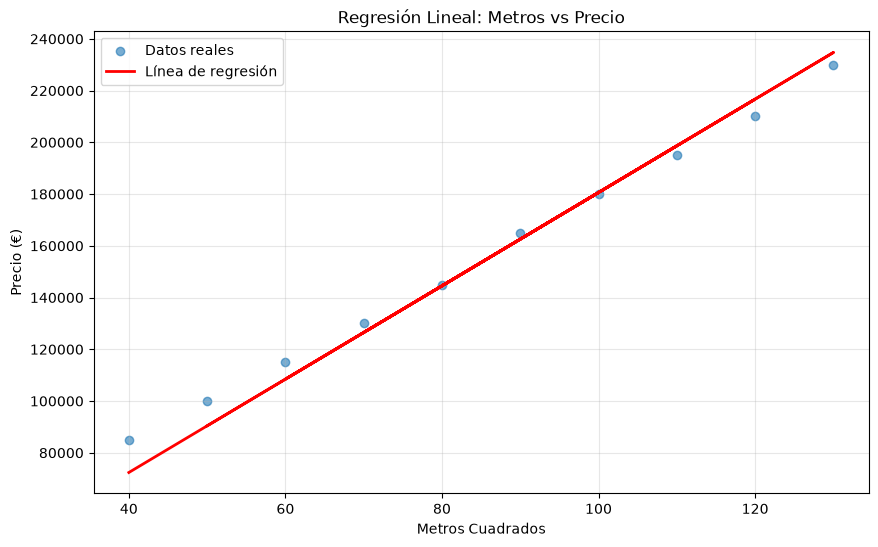

In [ ]:
X = df['metros_cuadrados'].values
y = df['precio'].values

# Predicciones
y_pred = w_final * X + b_final

print(y_pred)

# Graficar
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.6, label='Datos reales')
plt.plot(X, y_pred, 'r-', linewidth=2, label='Línea de regresión')
plt.xlabel('Metros Cuadrados')
plt.ylabel('Precio')
plt.title('Regresión Lineal: Metros vs Precio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()